<a href="https://colab.research.google.com/github/AlexJurcich/ecommerce-causal-discount-analysis/blob/main/E_Commerce_Pricing_Experiment_Simulator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **E-Commerce Pricing Experiment Simulator**

## **Alex Jurcich**

In this project, I evaluate the causal impact of a pricing discount on e-commerce revenue using an experimental and quasi-experimental framework. While discounts often increase conversion rates, their true effect on net revenue is not always straightforward due to selection bias and user heterogeneity. I simulate a realistic pricing experiment in which higher-value customers are more likely to receive a discount, creating a biased treatment assignment. I first estimate the naive treatment effect and then apply propensity score modeling and inverse probability weighting (IPTW) to correct for selection bias and recover an unbiased estimate of the causal impact. Finally, I explore heterogeneous treatment effects to identify which customer segments benefit most from the discount strategy. This project demonstrates how causal inference techniques can guide revenue-optimizing decisions beyond simple predictive modeling.

In [127]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from sklearn.linear_model import LogisticRegression

np.random.seed(11)

## **Create Dataset**

In [114]:
# Number of rows
n = 100000

# How good of a customer someone is
user_value_score = np.random.normal(0,1,n)

### Baseline (no-discount) conversion probability

In [115]:
# Create a log-odds score that increases with user_value_score
baseline_logit = -1 + 0.8 * user_value_score

# Convert log-odds to probability with user_value_score
baseline_prob = 1 / (1 + np.exp(-baseline_logit))

### Treatment assignment (who gets a discount)

In [116]:
# Bias: higher-value users are more likely to receive a discount
treatment_logit = -0.5 + 0.6 * user_value_score


# Convert log-odds to probability with user_value_score
treatment_prob = 1 / (1 + np.exp(-treatment_logit))

In [117]:
# Draw treatment status from Bernoulli(treatment_prob): 1 = discount, 0 = no discount
treatment = np.random.binomial(1, treatment_prob)

In [118]:
# Pricing Setup
base_price = 100
discount = 0.10

In [119]:
# Price Paid depends on treatment: treated pay less
price = base_price * (1- discount * treatment)

In [120]:
# True casual effect: discount increases conversion probability by +0.05
true_treatment_effect = 0.05

In [121]:
# Final conversion probability = baseline + treatment lift
conversion_logit = baseline_logit + treatment * 0.5

# Ensure probabilites stay within [0,1]
conversion_prob = 1 / (1 + np.exp(-conversion_logit))

# Purchase outcome drawn from Bernoulli(conversion_prob): 1 = bought, 0 = did not buy
conversion = np.random.binomial(1, conversion_prob)

# Revenue: only earned if a purchase occurs
revenue = price * conversion

In [122]:
# Final simulated dataset
data = pd.DataFrame({
    "user_id": np.arange(n),
    "user_value_score": user_value_score,
    "baseline_prob": baseline_prob,
    "treatment": treatment,
    "price": price,
    "conversion": conversion,
    "revenue": revenue
})

## **Treatment Assignment & Selection Bias**

In [123]:
# Check if treated customers are stronger customers
data.groupby("treatment")["user_value_score"].mean()

,user_value_score
treatment,
0,-0.212963
1,0.354558


Treated users have a significantly higher average customer value score than control users, confirming that discount assignment was biased toward stronger customers.

In [124]:
# Check baseline conversion differences
data.groupby("treatment")["baseline_prob"].mean()

,baseline_prob
treatment,
0,0.260842
1,0.346245


Even before the discount, treated users were already much more likely to purchase.

In [125]:
# Check observed outcome
data.groupby("treatment")[["conversion", "revenue"]].mean()

,conversion,revenue
treatment,,
0,0.260127,26.012664
1,0.453339,40.800496


Treated users have a substantially higher average conversion rate and revenue than control users under a naive comparison, suggesting a strong positive effect of the discount without adjusting for selection bias.

## **Naive Treatment Effect Estimation**

In [126]:
# Naive ATE: difference in mean revenue between treated and control groups (no bias adjustment)
naive_ate = (
    data.loc[data["treatment"] == 1, "revenue"].mean()
    - data.loc[data["treatment"] == 0, "revenue"].mean()
)

naive_ate

np.float64(14.78783136557347)

The naive comparison suggests that offering a discount increases revenue by about $14.79 per user, ignoring any selection bias.

## **Propensity Score Modeling**

A propensity score is the estimated probability that a user received the treatment (discount), given their characteristics.

In [128]:
# Fit propensity score model
ps_model = LogisticRegression()
ps_model.fit(data[["user_value_score"]], data["treatment"])

# Predicted propensity scores
data["propensity_score"] = ps_model.predict_proba(data[["user_value_score"]])[:, 1]

data["propensity_score"].head()

,propensity_score
0,0.640036
1,0.336501
2,0.309758
3,0.105476
4,0.375725


In [129]:
# Check for overlap
data.groupby("treatment")["propensity_score"].describe()

,count,mean,std,min,25%,50%,75%,max
treatment,,,,,,,,
0,61274.0,0.357318,0.127303,0.040436,0.262545,0.346569,0.442586,0.856910
1,38726.0,0.434613,0.134522,0.052723,0.335238,0.429614,0.528364,0.919206


A logistic regression model was used to estimate each user’s probability of receiving the discount based on their customer value score, generating individual propensity scores. The treated and control groups show overlapping propensity distributions, satisfying the overlap assumption required for valid causal adjustment.

## **Inverse Probability of Treatment Weighting (IPTW)**

IPTW reweights observations using their propensity scores to simulate a randomized experiment and reduce selection bias.

In [131]:
# IPTW weights
data["weight"] = np.where(
    data["treatment"] == 1,
    1 / data["propensity_score"],
    1 / (1 - data["propensity_score"])
)

In [132]:
# Weighted (IPTW) ATE
weighted_ate = (
    np.average(
        data.loc[data["treatment"] == 1, "revenue"],
        weights=data.loc[data["treatment"] == 1, "weight"]
    )
    -
    np.average(
        data.loc[data["treatment"] == 0, "revenue"],
        weights=data.loc[data["treatment"] == 0, "weight"]
    )
)

weighted_ate

np.float64(6.087035127638387)

The naive estimate overstated the impact because treated users were higher-value customers; IPTW rebalances the groups and produces a more credible causal effect estimate.

## **Covariate Balance After Weighting**

In [136]:
# Mean user_value_score before weighting
before = data.groupby("treatment")["user_value_score"].mean()

before

,user_value_score
treatment,
0,-0.212963
1,0.354558


In [140]:
# Mean user_value_score after weighting
after_treated = np.average(
    data.loc[data["treatment"] == 1, "user_value_score"],
    weights=data.loc[data["treatment"] == 1, "weight"]
)

after_control = np.average(
    data.loc[data["treatment"] == 0, "user_value_score"],
    weights=data.loc[data["treatment"] == 0, "weight"]
)

print(f'After Treated: {np.round(after_treated,4)}')
print(f'After Control: {np.round(after_control,4)}')

After Treated: 0.0085
After Control: 0.0074


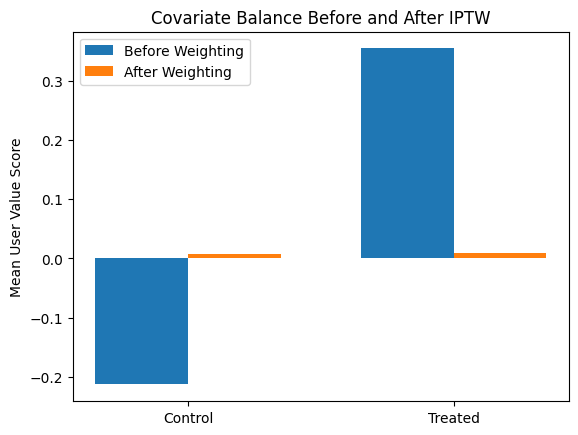

In [141]:
before_means = data.groupby("treatment")["user_value_score"].mean().values

after_means = np.array([after_control, after_treated])

# Plot
labels = ["Control", "Treated"]
x = np.arange(len(labels))

fig, ax = plt.subplots()

ax.bar(x - width/2, before_means, width, label="Before Weighting")
ax.bar(x + width/2, after_means, width, label="After Weighting")

ax.set_ylabel("Mean User Value Score")
ax.set_title("Covariate Balance Before and After IPTW")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

plt.show()

Before weighting, treated users had a substantially higher average customer value score than control users, indicating strong selection bias. After applying IPTW, the weighted means of the confounder were nearly identical across groups, confirming that the weighting procedure successfully balanced the covariate and reduced bias.

## **Bootstrap Confidence Interval**

A bootstrap confidence interval estimates uncertainty by repeatedly resampling the data and recalculating the statistic to approximate its sampling distribution.

In [143]:
# Number of bootstrap resamples
n_boot = 500

# Store bootstrap ATE estimates
boot_estimates = []

for _ in range(n_boot):

    # Resample dataset with replacement
    sample = data.sample(frac=1, replace=True)

    # Split into treated and control groups
    treated = sample[sample["treatment"] == 1]
    control = sample[sample["treatment"] == 0]

    # Compute weighted mean revenue for each group
    weighted_treated_mean = np.average(
        treated["revenue"],
        weights=treated["weight"]
    )

    weighted_control_mean = np.average(
        control["revenue"],
        weights=control["weight"]
    )

    # Store weighted ATE for this bootstrap sample
    boot_estimates.append(weighted_treated_mean - weighted_control_mean)

In [144]:
# Convert to numpy array
boot_estimates = np.array(boot_estimates)

# Compute 95% confidence interval
ci_lower = np.percentile(boot_estimates, 2.5)
ci_upper = np.percentile(boot_estimates, 97.5)

print(f"Weighted ATE: ${weighted_ate:.2f}")
print(f"95% Confidence Interval: (${ci_lower:.2f}, ${ci_upper:.2f})")

Weighted ATE: $6.09
95% Confidence Interval: ($5.50, $6.67)


After adjusting for selection bias using IPTW, the discount increases revenue by approximately 6.09 per user, with a 95% confidence interval of 5.50 to 6.67, indicating a statistically significant positive causal effect.

## **Causal Assumptions**

**Unconfoundedness** **(No Unobserved Confounding)**: After controlling for `user_value_score`, treatment assignment is independent of potential outcomes, meaning no additional hidden variables influence both discount assignment and revenue.

**Overlap (Positivity)**: For all values of `user_value_score`, users have a positive probability of being both treated and untreated, ensuring meaningful comparison across groups.

**Correct Model Specification**: The propensity score model is correctly specified, accurately capturing the relationship between customer value and treatment assignment.

## **Limitations**

**Unobserved Confounding**: The analysis assumes that `user_value_score` fully captures all factors influencing both treatment assignment and revenue; in real-world settings, unmeasured variables could still bias the results.

**Model Dependence**: The validity of the IPTW adjustment relies on correct specification of the propensity score model, and misspecification could lead to incomplete bias correction.

**Simulated Data Environment**: Because this analysis is conducted on simulated data with a known data-generating process, real-world applications may involve additional complexity, noise, and operational constraints not captured here.

## **Summary**

After correcting for selection bias using propensity score weighting, the estimated revenue impact of the discount decreased substantially from the naive estimate, demonstrating that much of the apparent effect was driven by differences in underlying customer quality. By restoring covariate balance and quantifying uncertainty with a bootstrap confidence interval, this analysis provides a more credible estimate of the true causal impact of the pricing strategy.

For stakeholders, this implies that scaling the discount strategy without careful targeting may generate less additional revenue than expected, and pricing decisions should be based on causal impact rather than raw performance comparisons.